In [ ]:
## importing libraries
import torch
import torch.nn as nn
from torch.optim import Adam
import torchvision
from torchvision.transforms import transforms
from torch.utils.data import Dataset , DataLoader
import numpy as np
from PIL import Image 
import os 

In [ ]:
path_train_sample = "/kaggle/input/datasets/oxcdcd/cifar10/cifar10/train"
## contains 10 classes

In [ ]:
transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize( # scaling -1 to 1
        mean = (0.5,0.5,0.5),
        std = (0.5,0.5,0.5)
    )
])

In [ ]:
from torchvision.datasets import ImageFolder
## the dataset files are arranged according to standard file format required for ImageFolder 
cifar_dataset = ImageFolder(root=path_train_sample, transform=transforms)
cifar_loader = DataLoader(
    dataset=cifar_dataset, 
    batch_size=128, 
    shuffle=True, 
    num_workers=2
)

In [ ]:
for x,y in cifar_loader:
    break 

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, half_batch):
        super().__init__()
        self.half_batch = half_batch

        self.discriminator = nn.Sequential(
            # Input: (batch_size, 3, 32, 32)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=2, padding=1), # -> (batch_size, 32, 16, 16)
            nn.BatchNorm2d(num_features=32),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1), # -> (batch_size, 64, 8, 8)
            nn.BatchNorm2d(num_features=64),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1), # -> (batch_size, 128, 4, 4)
            nn.BatchNorm2d(num_features=128),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=2, padding=1), # -> (batch_size, 256, 2, 2)
            nn.BatchNorm2d(num_features=256),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Flatten(), # Flattens to: batch_size, (256 * 2 * 2) = 1024
            nn.Linear(in_features=256 * 2 * 2, out_features=1), # Exactly 1024 input features
            nn.Sigmoid()
        )

    def generate_real_sample(self,train_dataset:Dataset):
      x = []
      for i in range(self.half_batch):
        rand_idx = np.random.randint(0,len(train_dataset)-1)
        image,_ = train_dataset[rand_idx]
        x.append(image)
      x = torch.stack(x)
      y = torch.ones((self.half_batch,1))
      return x,y

    def generate_fake_sample(self):
        # Correct 4D shape: (batch_size, channels, height, width)
        x = torch.rand(self.half_batch, 3, 32, 32)
        # Match labels to the actual batch size dimension
        y = torch.zeros((self.half_batch, 1))
        return x, y

    def forward(self, X):
        """ Match case: Change internal 'x' variable to track input parameter 'X' it cal take real as well as fake """
        y = self.discriminator(X)
        return y


In [ ]:
from torch.nn.modules.activation import LeakyReLU
class Generator(nn.Module):
  def __init__(self,latent_dim,half_batch):
    super().__init__()
    self.n_nodes = 4*4*256
    self.half_batch = half_batch
    self.latent_dim = latent_dim
    self.fc = nn.Linear(in_features=latent_dim,out_features=self.n_nodes)
    self.upscaling = nn.Sequential(
       nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=4, stride=2, padding=1), ## (128,8,8)
       nn.LeakyReLU(0.2),
       nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=4, stride=2, padding=1), ## (128,16,16)
       nn.LeakyReLU(0.2),
       nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=4, stride=2, padding=1), ## (128,32,32)
       nn.LeakyReLU(0.2),
       nn.ConvTranspose2d(in_channels=128, out_channels=3, kernel_size=3,padding=1), # (3,32,32)
       nn.Tanh()
    )
  def generate_latent_sample(self):
    samples = torch.rand(self.latent_dim*self.half_batch)
    samples = samples.reshape((self.half_batch,self.latent_dim))
    return samples
  def forward(self,z):
    """ here we get latent dim (100 vector) as input and generate 32,32,3 image """
    x = self.fc(z)
    x = x.reshape(-1,256,4,4) # (batch_size,256,4,4)
    z = self.upscaling(x)
    return z # (3,32,32) # image

In [ ]:
latent_dim = 100
batch_size = 128
half_batch = int(batch_size / 2)
batch_per_epoch = int(len(cifar_dataset) / batch_size)
device = "cuda" if torch.cuda.is_available() else "cpu"
num_epochs = 20

In [ ]:
model_g = Generator(latent_dim = latent_dim,half_batch=half_batch).to(device)
lr = 0.0002
model_d = Discriminator(half_batch = half_batch).to(device)
optim_d = Adam(model_d.parameters(),lr=lr, betas=(0.5, 0.999))
optim_g = Adam(model_g.parameters(),lr=lr, betas=(0.5, 0.999))
criterion = nn.BCELoss()

In [ ]:
## training loop 
for epoch in range(num_epochs):
    for i in range(batch_per_epoch): ## batches per epoch
        ## training discriminator 
        optim_d.zero_grad()
        X_real,y_real = model_d.generate_real_sample(cifar_dataset)
        X_real, y_real = X_real.to(device), y_real.to(device)
        y_pred_real = model_d(X_real)
        loss_real = criterion(y_pred_real,y_real)

        z_sample = model_g.generate_latent_sample().to(device) # return the 100th dim 64 vectors
        X_fake = model_g(z_sample).detach()
        y_fake = torch.zeros((half_batch,1)).to(device)
        y_pred_fake = model_d(X_fake)
        loss_fake = criterion(y_pred_fake,y_fake)

        loss_d = loss_real + loss_fake
        loss_d.backward()
        optim_d.step()

        ## training generator
        optim_g.zero_grad()
        z_sample = model_g.generate_latent_sample().to(device)
        X_fake = model_g(z_sample)
        y_fake = torch.ones((half_batch,1)).to(device) ## tries to check weather discriminator will fool 
        y_pred = model_d(X_fake)
        loss_fake = criterion(y_pred,y_fake)
        loss_fake.backward()
        optim_g.step()
        
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss D: {loss_d.item():.4f} | Loss G: {loss_fake.item():.4f}")

## done 

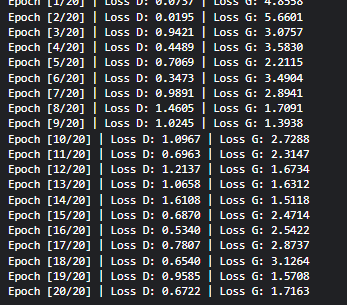

In [ ]:
cifar_dataset[0][0].shape

In [ ]:
def pick_random_sample(cifa_dataset):
    rand_index = np.random.randint(0,len(cifar_dataset)-1)
    x = cifar_dataset[rand_index][0].unsqueeze(0)
    return x

In [ ]:
x = pick_random_sample(cifar_dataset)
import matplotlib.pyplot as plt 
plt.subplot(1,2,1)
x = x.squeeze(0).permute(1, 2, 0).numpy()
plt.imshow(x)
plt.title("Original Image")

In [ ]:
import time 
model_g.eval()
i = 10
while(i!=0):
    with torch.inference_mode():
        time.sleep(1)
        original_half_batch = model_g.half_batch
        model_g.half_batch = 1 # only iterating one sample
        z_sample = model_g.generate_latent_sample().to(device)
        model_g.half_batch = original_half_batch
        X_pred = model_g(z_sample)
        X_pred = (X_pred.squeeze(0).cpu().permute(1, 2, 0).numpy() + 1) / 2 # denormalizeing from -1to 1 to 0 to1 
        plt.figure(figsize=(4, 4))
        plt.imshow(X_pred)
        plt.title("Generated Image")
        plt.axis("off")
        plt.show()
        i -=1

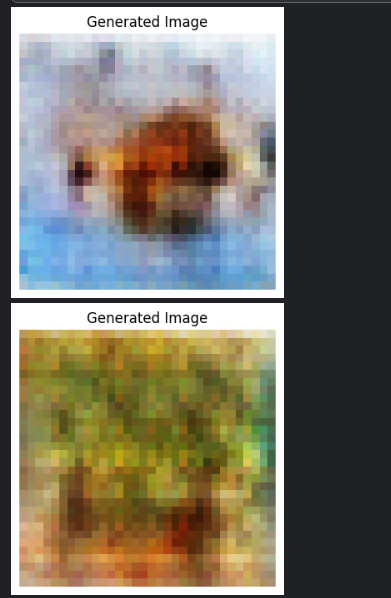

### Let's train for 100 epochs 